# U-Net Model Training for Fault Segmentation (PyTorch)

## ✅ Environment / Kernel (Run this first)
- **Kernel to select in VS Code:** `Python 3.13.10 (.venv/bin/python)`
- **Activate in terminal:**
  ```bash
  cd /home/roderickperez/DataScienceProjects/faultSeg
  source .venv/bin/activate
  ```

In [1]:
import sys
import importlib
print("Python executable:", sys.executable)
for module_name in ["tensorflow", "keras", "torch"]:
    try:
        module = importlib.import_module(module_name)
        print(f"{module_name}: {module.__version__}")
    except Exception as error:
        print(f"{module_name}: not available ({error})")
try:
    import tensorflow as tf
    print("TF GPUs:", tf.config.list_physical_devices("GPU"))
except Exception as error:
    print("TF GPU check failed:", error)
try:
    import torch
    print("Torch CUDA:", torch.cuda.is_available(), "devices:", torch.cuda.device_count())
except Exception as error:
    print("Torch CUDA check failed:", error)


Python executable: /home/roderickperez/DataScienceProjects/faultSeg/.venv/bin/python


2026-03-14 01:36:52.584882: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow: 2.20.0
keras: 3.13.2
torch: 2.5.1+cu121
TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Torch CUDA: True devices: 1


## Step 1: Import Libraries

First, we import all the necessary libraries. This includes standard libraries like `os` and `numpy`, deep learning libraries from `torch`, and the custom modules `DataGenerator` and `unet` from our project.

In [2]:
from tqdm import tqdm
import glob
import os
import shutil
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim
# Project‑local code
from utils_pytorch import DataGenerator
from unet3_pytorch import unet, cross_entropy_balanced


In [3]:
try:
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))  # for .py scripts
except NameError:
    ROOT_DIR = os.getcwd()  # for Jupyter notebooks


## Step 1a: Verify GPU Availability
This cell checks whether PyTorch can detect a CUDA GPU and prints the selected device for training.

In [4]:
# Check whether CUDA is available and configure deterministic behaviour.
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU detected -> using {torch.cuda.get_device_name(0)}")
    # (Optional) set cudnn benchmark / deterministic flags according to your needs
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")
    print("No GPU detected.  Running on CPU.")


GPU detected -> using NVIDIA RTX A5000


## Step 2: Define Paths and Parameters

In [5]:
# --- Input: Original .dat directories ---
# Resolve source data root robustly for both notebook and script execution contexts.
candidate_base_dirs = [
    os.path.abspath(os.path.join(ROOT_DIR, "..", "data", "data_from_Wu")),
    os.path.abspath(os.path.join(ROOT_DIR, "..", "..", "data", "data_from_Wu")),
]
base_dir = next((path for path in candidate_base_dirs if os.path.isdir(path)), None)
if base_dir is None:
    raise FileNotFoundError(
        "Could not locate 'data_from_Wu'. Checked: " + ", ".join(candidate_base_dirs)
    )
train_seis_dir = os.path.join(base_dir, "train", "seis")
train_fault_dir = os.path.join(base_dir, "train", "fault")
validation_seis_dir = os.path.join(base_dir, "validation", "seis")
validation_fault_dir = os.path.join(base_dir, "validation", "fault")
prediction_seis_dir = os.path.join(base_dir, "prediction", "f3d")
# --- Output: Processed .npy directories ---
processed_data_dir = os.path.join(ROOT_DIR, "data")
train_dir_new = os.path.join(processed_data_dir, 'train_npy')
validation_dir_new = os.path.join(processed_data_dir, 'validation_npy')
prediction_dir_new = os.path.join(processed_data_dir, 'prediction_npy')
# --- Model/Log dirs ---
model_dir = os.path.join(ROOT_DIR, "model")
import tempfile
log_dir = os.path.join(tempfile.gettempdir(), "faultSeg_logs")
os.makedirs(log_dir, exist_ok=True)
checkpoint_dir = os.path.join(ROOT_DIR, "output", "checkpoints")
print(f"Using source base_dir: {base_dir}")
print(f"Log directory set to: {log_dir}")


Using source base_dir: /home/roderickperez/DataScienceProjects/faultSeg/data/data_from_Wu
Log directory set to: /tmp/faultSeg_logs


In [6]:
# --- Training Parameters ---
params = {
    'batch_size' : 1,          # effective batch (original + flipped)
    'dim'        : (128,128,128),
    'n_channels' : 1,
    'shuffle'    : True
}


In [7]:
epochs         = 25 #100
learning_rate  = 1e-4


## Step 3: Prepare Data

This step involves converting the original `.dat` files into the `.npy` format that our `DataGenerator` expects. We also split the data into training and validation sets. This is a crucial preprocessing step.

In [8]:
def convert_dat_to_npy():
    """Creates directories and converts .dat files to .npy format."""
    # Clean up old processed data folders AND log/checkpoint directories
    for folder in [train_dir_new, validation_dir_new, prediction_dir_new, log_dir, checkpoint_dir]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
            print(f"Removed old directory: {folder}")
    # Create new directory structure
    os.makedirs(os.path.join(train_dir_new, 'seis'), exist_ok=True)
    os.makedirs(os.path.join(train_dir_new, 'fault'), exist_ok=True)
    os.makedirs(os.path.join(validation_dir_new, 'seis'), exist_ok=True)
    os.makedirs(os.path.join(validation_dir_new, 'fault'), exist_ok=True)
    os.makedirs(os.path.join(prediction_dir_new, 'seis'), exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(checkpoint_dir, exist_ok=True)
    print("Created new directory structure for processed data and model artifacts.")
    def process_files(file_list, source_seis, source_fault, dest_dir, strict_shape=True, save_fault=True):
        """Reads .dat, reshapes, and saves as .npy."""
        volume_size = np.prod(params['dim'])
        for filename in file_list:
            seis_dat_path = os.path.join(source_seis, filename)
            seis_npy_path = os.path.join(dest_dir, 'seis', filename.replace('.dat', '.npy'))
            seismic_data = np.fromfile(seis_dat_path, dtype=np.single)
            if seismic_data.size == volume_size:
                seismic_data = seismic_data.reshape(params['dim'])
                np.save(seis_npy_path, seismic_data)
            elif seismic_data.size % volume_size == 0:
                num_volumes = seismic_data.size // volume_size
                seismic_data = seismic_data.reshape((num_volumes, *params['dim']))
                for i in range(num_volumes):
                    sub_volume = seismic_data[i]
                    volume_name = filename.replace('.dat', f'_vol{i+1}.npy')
                    np.save(os.path.join(dest_dir, 'seis', volume_name), sub_volume)
                print(f"🔁 Split {filename} into {num_volumes} volumes.")
                continue
            else:
                message = f"Unexpected shape for file {filename} with {seismic_data.size} elements."
                if strict_shape:
                    raise ValueError(f"❌ {message}")
                print(f"⚠️ {message} Skipping this file.")
                continue
            if save_fault:
                fault_dat_path = os.path.join(source_fault, filename)
                fault_npy_path = os.path.join(dest_dir, 'fault', filename.replace('.dat', '.npy'))
                if os.path.exists(fault_dat_path):
                    fault_data = np.fromfile(fault_dat_path, dtype=np.single).reshape(params['dim'])
                    np.save(fault_npy_path, fault_data)
        print(f"Processed {len(file_list)} files for {os.path.basename(dest_dir)}.")
    train_dat_files = [f for f in os.listdir(train_seis_dir) if f.endswith('.dat')]
    validation_dat_files = [f for f in os.listdir(validation_seis_dir) if f.endswith('.dat')]
    if os.path.exists(prediction_seis_dir):
        all_prediction_dat_files = [f for f in os.listdir(prediction_seis_dir) if f.endswith('.dat')]
        prediction_dat_files = [f for f in all_prediction_dat_files if 'gxl' in f.lower()]
        if not prediction_dat_files:
            print(f"⚠️ Warning: No prediction source file matching 'gxl' found in '{prediction_seis_dir}'.")
    else:
        prediction_dat_files = []
        print(f"⚠️ Warning: Prediction folder '{prediction_seis_dir}' not found. Skipping prediction data.")
    print("\nStarting data conversion...")
    process_files(train_dat_files, train_seis_dir, train_fault_dir, train_dir_new, strict_shape=True, save_fault=True)
    process_files(validation_dat_files, validation_seis_dir, validation_fault_dir, validation_dir_new, strict_shape=True, save_fault=True)
    process_files(prediction_dat_files, prediction_seis_dir, prediction_seis_dir, prediction_dir_new, strict_shape=False, save_fault=False)
    print("\n✅ Data preparation complete. All compatible .dat files converted to .npy.")


## Step 4: Create Data Generators

Now that our data is in the correct format and location, we can use the `DataGenerator` from `utils.py` to feed it to our model efficiently. We create one generator for the training set and one for the validation set.

In [9]:
# Build PyTorch datasets & loaders
train_ID = [os.path.splitext(f)[0] for f in os.listdir(os.path.join(train_dir_new, "seis"))]
valid_ID = [os.path.splitext(f)[0] for f in os.listdir(os.path.join(validation_dir_new, "seis"))]
train_dataset = DataGenerator(dpath=os.path.join(train_dir_new, 'seis/'),
                              fpath=os.path.join(train_dir_new, 'fault/'),
                              data_IDs=train_ID,
                              dim=params['dim'],
                              split='train',
                              augment=True)
valid_dataset = DataGenerator(dpath=os.path.join(validation_dir_new, 'seis/'),
                              fpath=os.path.join(validation_dir_new, 'fault/'),
                              data_IDs=valid_ID,
                              dim=params['dim'],
                              split='val',
                              augment=False)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=params['shuffle'], num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False,             num_workers=4)
print("Number of training pairs :", len(train_ID))
print("Number of validation pairs:", len(valid_ID))


Number of training pairs : 200
Number of validation pairs: 20


## Step 5: Build and Compile the Model

We will now use the `unet` function from `unet3.py` to build our model architecture. After building it, we compile it with an optimizer, a loss function, and metrics to monitor.

In [10]:
model = unet().to(device)
optimiser = optim.Adam(model.parameters(), lr=learning_rate)
criterion = cross_entropy_balanced
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")


Model has 1,459,585 trainable parameters


## Step 6: Define Callbacks
In this PyTorch version, we use equivalent checkpoint and logging utilities instead of Keras callback objects.

In [11]:
# Torch equivalent of callbacks
writer = SummaryWriter(log_dir)
os.makedirs(checkpoint_dir, exist_ok=True)
def save_ckpt(epoch):
    fname = os.path.join(checkpoint_dir, f"fseg-{epoch:02d}.pth")
    torch.save(model.state_dict(), fname)


## Step 7: Train the Model

With everything set up, we can now start training the model using the `fit` method. The training and validation data will be provided through our generators.

In [12]:
from tqdm.auto import tqdm
import os, glob
FORCE_RE_TRAIN = True
final_model_path = os.path.join(model_dir, "fseg_final.pth")
# Check for any existing model if fseg_final.pth is missing
existing_models = glob.glob(os.path.join(model_dir, "*.pth"))
if not os.path.exists(final_model_path) and existing_models:
    # Use the most recent one as the 'exists' check
    latest_model = max(existing_models, key=os.path.getmtime)
    print(f" [INFO] Found existing model(s), latest: {latest_model}")
    # Optionally symlink or just use it, but for simplicity let's just use it for the skip check
    final_model_path = latest_model
if os.path.exists(final_model_path) and not FORCE_RE_TRAIN:
    print(f"{'='*60}")
    print(f" [INFO] Baseline model already exists at: {final_model_path}")
    print(f" [INFO] Skipping training. Set FORCE_RE_TRAIN = True to overwrite.")
    print(f"{'='*60}")
    
    # Pre-load history for plotting
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    hist_npz = os.path.join(ROOT_DIR, "output", "history_plots", "history.npz")
    if os.path.exists(hist_npz):
        data = np.load(hist_npz)
        history = {k: data[k].tolist() for k in data.files}
        print(f" ✅ Loaded existing history from {hist_npz}")
    else:
        print(f" ⚠️ Model exists but {hist_npz} is missing.")
        print(f" [TIP] Run training once with FORCE_RE_TRAIN = True to generate comparison data.")
else:
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    for epoch in range(1, epochs + 1):
        # ---- training ----
        model.train()
        epoch_loss, epoch_acc = 0.0, 0.0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs} [Train]")
        for X, Y in train_pbar:
            X, Y = X.to(device), Y.to(device)
            optimiser.zero_grad()
            preds = model(X)
            loss  = criterion(preds, Y)
            loss.backward()
            optimiser.step()
            batch_loss = loss.item()
            batch_acc = (preds.round() == Y).float().mean().item()
            
            epoch_loss += batch_loss
            epoch_acc  += batch_acc
            
            train_pbar.set_postfix({'loss': f"{batch_loss:.4f}", 'acc': f"{batch_acc:.4f}"})
        epoch_loss /= len(train_loader)
        epoch_acc  /= len(train_loader)
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        writer.add_scalar('Loss/train',  epoch_loss, epoch)
        writer.add_scalar('Acc/train',   epoch_acc,  epoch)
        # ---- validation ----
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        with torch.no_grad():
            val_pbar = tqdm(valid_loader, desc=f"Epoch {epoch:02d}/{epochs} [Val]  ")
            for X, Y in val_pbar:
                X, Y = X.to(device), Y.to(device)
                preds = model(X)
                loss  = criterion(preds, Y)
                
                batch_loss = loss.item()
                batch_acc = (preds.round() == Y).float().mean().item()
                
                val_loss += batch_loss
                val_acc  += batch_acc
                
                val_pbar.set_postfix({'loss': f"{batch_loss:.4f}", 'acc': f"{batch_acc:.4f}"})
        val_loss /= len(valid_loader)
        val_acc  /= len(valid_loader)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        writer.add_scalar('Loss/val',  val_loss, epoch)
        writer.add_scalar('Acc/val',   val_acc,  epoch)
        print(f"Epoch {epoch:02d}/{epochs} Summary | train_loss {epoch_loss:.4f} - train_acc {epoch_acc:.4f} | val_loss {val_loss:.4f} - val_acc {val_acc:.4f}\n")
        save_ckpt(epoch)
    # Save stable final path
    torch.save(model.state_dict(), final_model_path)
    print(f"[INFO] Saved final model to: {final_model_path}")
    writer.close()


/home/roderickperez/DataScienceProjects/faultSeg/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 [INFO] Found existing model(s), latest: /home/roderickperez/DataScienceProjects/faultSeg/faultSeg_2019/faultSeg_2019_pyTorch/model/unet_pytorch_model_200pairs_25epochs_2026-03-14_01-32-23.pth


Epoch 01/25 [Val]  : 100%|██████████| 20/20 [00:02<00:00,  9.52it/s, loss=0.0775, acc=0.7787]


Epoch 01/25 Summary | train_loss 0.0726 - train_acc 0.7018 | val_loss 0.0550 - val_acc 0.8199



Epoch 02/25 [Val]  : 100%|██████████| 20/20 [00:01<00:00, 10.17it/s, loss=0.0694, acc=0.8349]


...

Epoch 23/25 Summary | train_loss 0.0167 - train_acc 0.9433 | val_loss 0.0180 - val_acc 0.9456



Epoch 24/25 [Val]  : 100%|██████████| 20/20 [00:01<00:00, 11.72it/s, loss=0.0263, acc=0.9260]


Epoch 24/25 Summary | train_loss 0.0164 - train_acc 0.9444 | val_loss 0.0184 - val_acc 0.9391



Epoch 25/25 [Val]  : 100%|██████████| 20/20 [00:01<00:00, 10.55it/s, loss=0.0252, acc=0.9306]


Epoch 25/25 Summary | train_loss 0.0162 - train_acc 0.9449 | val_loss 0.0171 - val_acc 0.9430

[INFO] Saved final model to: /home/roderickperez/DataScienceProjects/faultSeg/faultSeg_2019/faultSeg_2019_pyTorch/model/unet_pytorch_model_200pairs_25epochs_2026-03-14_01-32-23.pth


## Step 8: Save the Final Model

After training is complete, we save the final model to the `model` directory for future use.

In [13]:
now = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model_name = f"unet_pytorch_model_{len(train_ID)}pairs_{epochs}epochs_{now}.pth"
model_path = os.path.join(model_dir, model_name)
torch.save(model.state_dict(), model_path)
print(f"Final model saved to: {model_path}")


Final model saved to: /home/roderickperez/DataScienceProjects/faultSeg/faultSeg_2019/faultSeg_2019_pyTorch/model/unet_pytorch_model_200pairs_25epochs_2026-03-14_01-57-12.pth


## Step 9: Visualize Training History

Finally, we visualize the training and validation accuracy and loss over the epochs. This helps us understand how well the model has learned.

In [14]:
def show_history(hist, save_path=None):
    print("Plotting training history...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    ax1.plot(hist['accuracy'],     label='Training Accuracy', color='b', marker='o')
    ax1.plot(hist['val_accuracy'], label='Validation Accuracy', color='r', marker='o', linestyle='--')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right', fontsize=12)
    ax1.grid(True)
    ax2.plot(hist['loss'],     label='Training Loss', color='b', marker='o')
    ax2.plot(hist['val_loss'], label='Validation Loss', color='r', marker='o', linestyle='--')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right', fontsize=12)
    ax2.grid(True)
    plt.tight_layout()
    plt.suptitle('PyTorch Model', fontsize = 18, y = 1.02)
    if save_path:
        plt.savefig(save_path)
        print(f"History plot saved to: {save_path}")
    plt.show()


Plotting training history...
History plot saved to: /home/roderickperez/DataScienceProjects/faultSeg/faultSeg_2019/faultSeg_2019_pyTorch/output/history_plots/unet_pytorch_model_200pairs_25epochs_2026-03-14_01-57-12_history.png


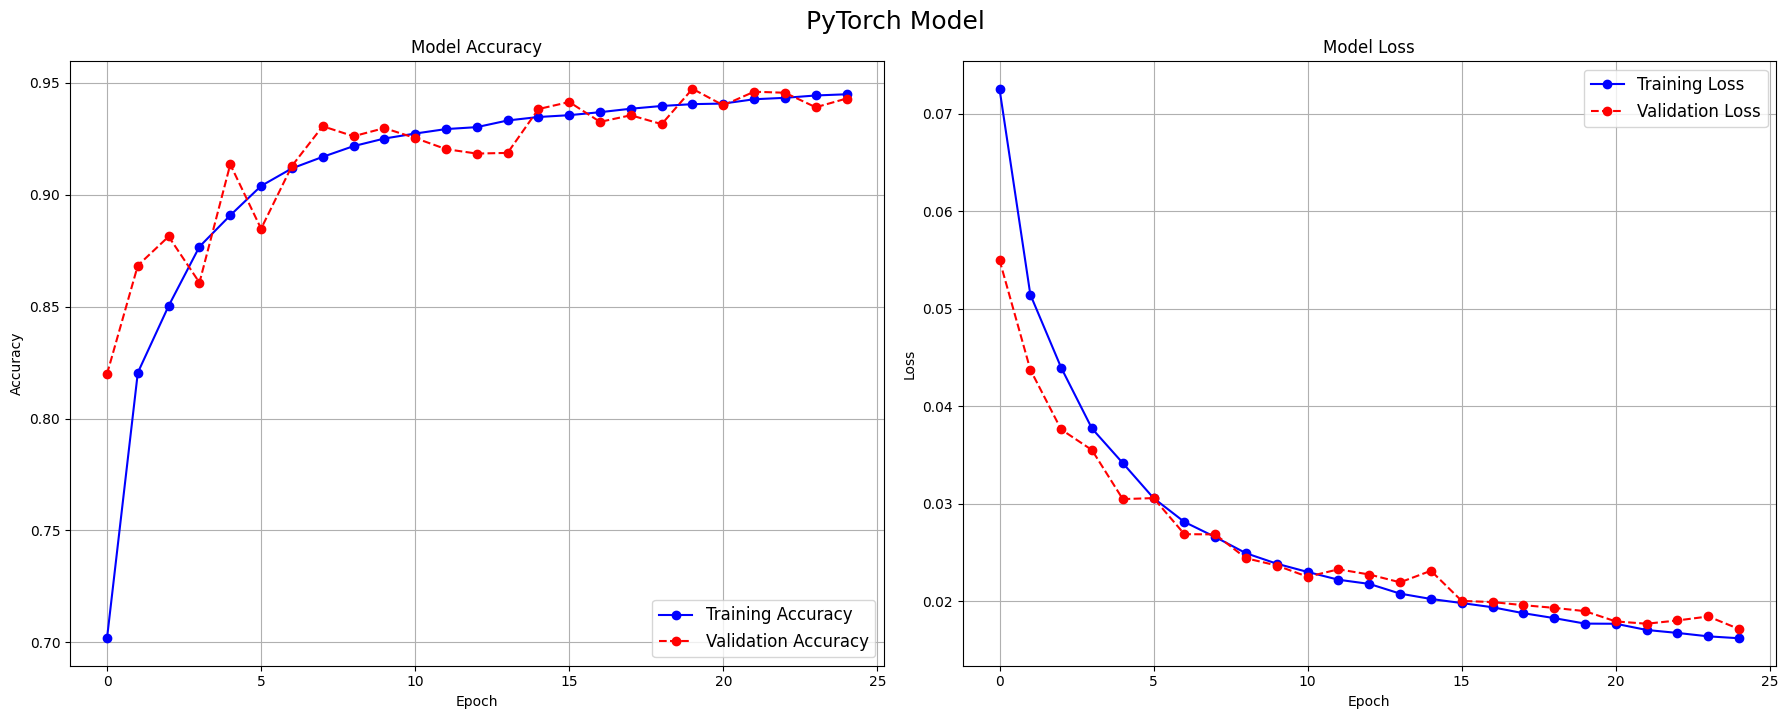

History data saved to: /home/roderickperez/DataScienceProjects/faultSeg/faultSeg_2019/faultSeg_2019_pyTorch/output/history_plots/history.npz


In [15]:
# 1) Build an output folder like “…/output/history_plots”
history_plot_dir = os.path.join(ROOT_DIR, "output", "history_plots")
os.makedirs(history_plot_dir, exist_ok=True)               # create if missing
# 2) Re-use the model filename to generate a matching plot name
base_name, _ = os.path.splitext(model_name)                # remove .pth
plot_name    = f"{base_name}_history.png"                  # e.g. …_history.png
plot_path    = os.path.join(history_plot_dir, plot_name)   # full absolute path
# 3) Draw & save
show_history(history, save_path=plot_path)
# Save history as NPZ for external comparison
np.savez(os.path.join(history_plot_dir, "history.npz"), 
         loss=np.array(history['loss']), 
         val_loss=np.array(history['val_loss']), 
         accuracy=np.array(history['accuracy']), 
         val_accuracy=np.array(history['val_accuracy']))
print(f"History data saved to: {os.path.join(history_plot_dir, 'history.npz')}")
